# Continuous Size Estimation — Using .pkl data

In [19]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import pickle
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split

print(f'TensorFlow: {tf.__version__}')
print(f'TF Hub:     {hub.__version__}')
print(f'GPUs:       {tf.config.list_physical_devices("GPU")}')

TensorFlow: 2.21.0
TF Hub:     0.16.1
GPUs:       []


## Configuration

In [20]:
TRAIN_PKL = '../data/folds-w-meta.pkl'
TEST_PKL  = '../data/test-w-meta.pkl'

EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'
ESTIMATE_IMAGE_SIZE = (224, 224)
BATCH_SIZE          = 32
ESTIMATOR_EPOCHS    = 20
SEED                = 12 

TRAIN_FOLDS = list(range(0, 9))
VAL_FOLDS   = [9]

# Bin definitions are kept around so we can still report bin-level accuracy
# at evaluation time for comparison with Silva — but the model trains on raw mm.
### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = ['25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None

In [21]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

train_pkl_folds = load_pkl(TRAIN_PKL)
test_pkl_folds  = load_pkl(TEST_PKL)

print(f'Train pkl folds: {len(train_pkl_folds)}')
print(f'Keys per fold:   {list(train_pkl_folds[0].keys())}')
print(f'Fold 0 size:     {len(train_pkl_folds[0]["data"])} fish')
print(f'Test pkl folds:  {len(test_pkl_folds)}')


Train pkl folds: 10
Keys per fold:   ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Fold 0 size:     63 fish
Test pkl folds:  1


In [22]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and
    (N,) float32 lengths in mm. Each fish contributes 9 image entries.
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            length_mm = float(length)

            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(length_mm)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [23]:
X_all, y_all = folds_to_arrays(train_pkl_folds + test_pkl_folds)
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train lengths — min: {y_train.min():.0f}mm, '
      f'max: {y_train.max():.0f}mm, mean: {y_train.mean():.1f}mm')
print(f'Test  lengths — min: {y_test.min():.0f}mm,  '
      f'max: {y_test.max():.0f}mm, mean: {y_test.mean():.1f}mm')

  Loaded 6246 images from 694 fish, skipped 0 fish

Train: 4996  Val: 625  Test: 625
Train lengths — min: 183mm, max: 910mm, mean: 492.4mm
Test  lengths — min: 183mm,  max: 910mm, mean: 495.7mm


In [24]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED).batch(BATCH_SIZE).prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

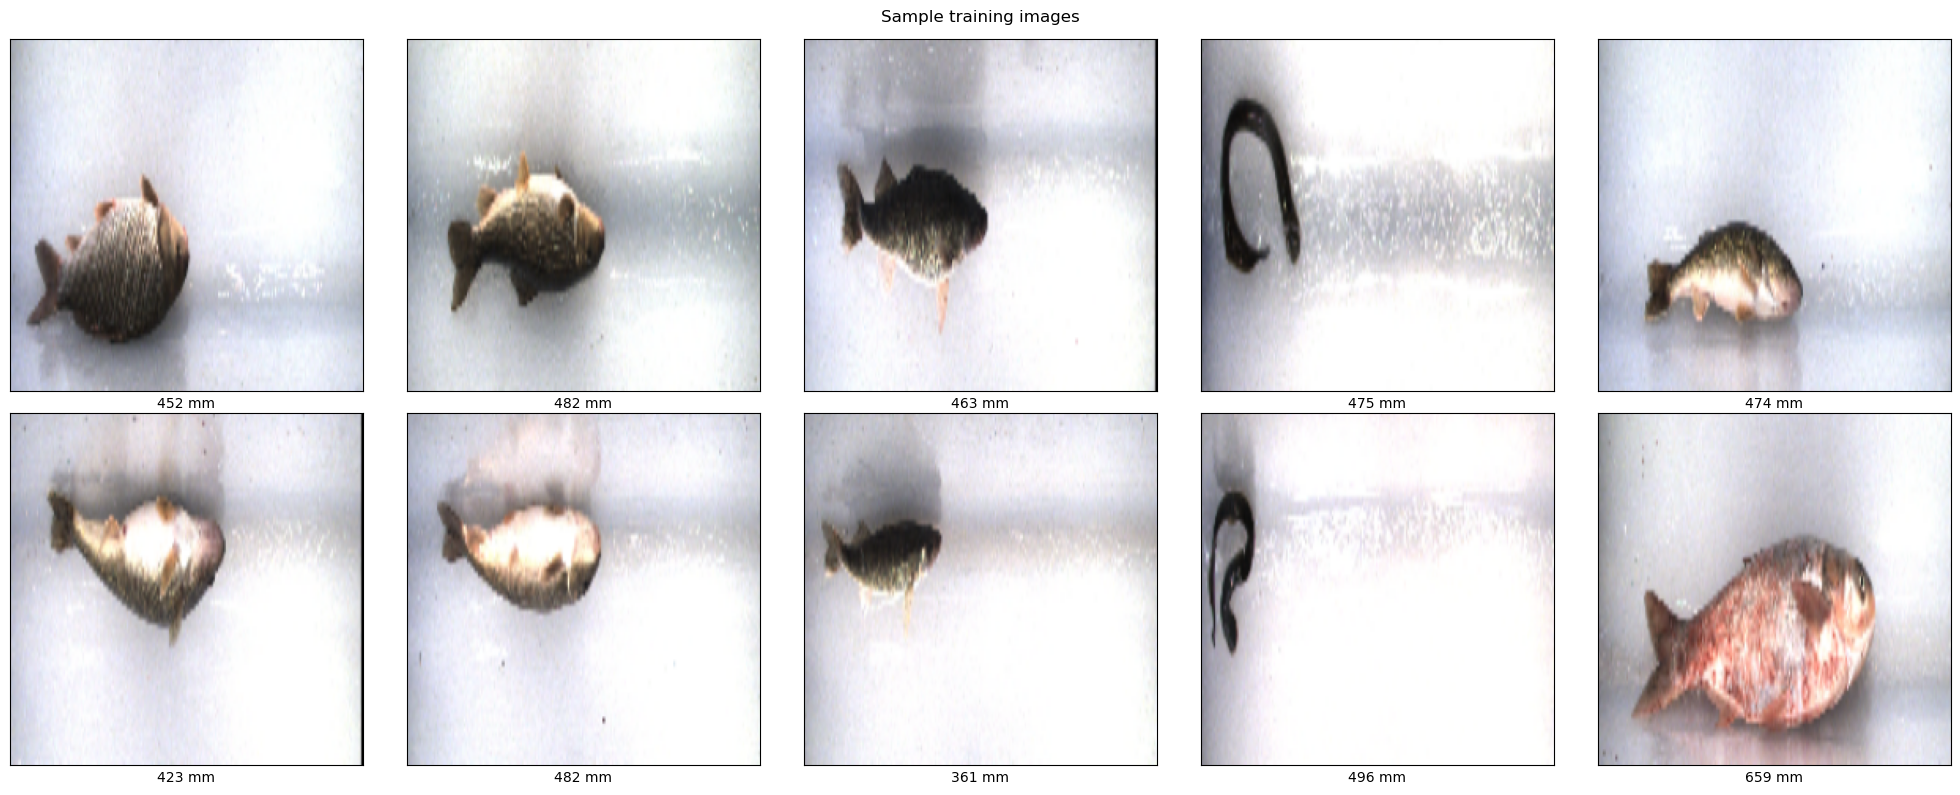

In [25]:
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{lbls[i].numpy():.0f} mm')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build model

In [26]:
def build_estimator(trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1),                       # single continuous output, no activation
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse',                                     
        metrics=['mae'],                                
    )
    return model

estimator = build_estimator(trainable_backbone=False)
estimator.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 224, 224, 3)       0         
                                                                 
 keras_layer_1 (KerasLayer)  (None, 1280)              3413024   
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               163968    
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 3577121 (13.65 MB)
Trainable params: 164097 (641.00 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train

In [27]:
early_stop = EarlyStopping(monitor='val_mae', mode='min', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS,
    callbacks=[early_stop],
)


Epoch 1/20
157/157 [==============================] - 18s 105ms/step - loss: 93456.2344 - mae: 247.9157 - val_loss: 12956.1348 - val_mae: 88.2881
Epoch 2/20
157/157 [==============================] - 16s 101ms/step - loss: 12431.2295 - mae: 87.6440 - val_loss: 9759.1396 - val_mae: 77.0884
Epoch 3/20
157/157 [==============================] - 16s 103ms/step - loss: 9409.6504 - mae: 76.4459 - val_loss: 7440.3242 - val_mae: 68.0213
Epoch 4/20
157/157 [==============================] - 16s 104ms/step - loss: 7491.3545 - mae: 67.9208 - val_loss: 5973.8467 - val_mae: 60.5455
Epoch 5/20
157/157 [==============================] - 16s 104ms/step - loss: 6128.9736 - mae: 61.2052 - val_loss: 5021.5957 - val_mae: 55.9386
Epoch 6/20
157/157 [==============================] - 16s 101ms/step - loss: 5305.8916 - mae: 56.7433 - val_loss: 4371.0894 - val_mae: 51.3994
Epoch 7/20
157/157 [==============================] - 16s 100ms/step - loss: 4911.8257 - mae: 54.1913 - val_loss: 3975.8721 - val_mae: 48.

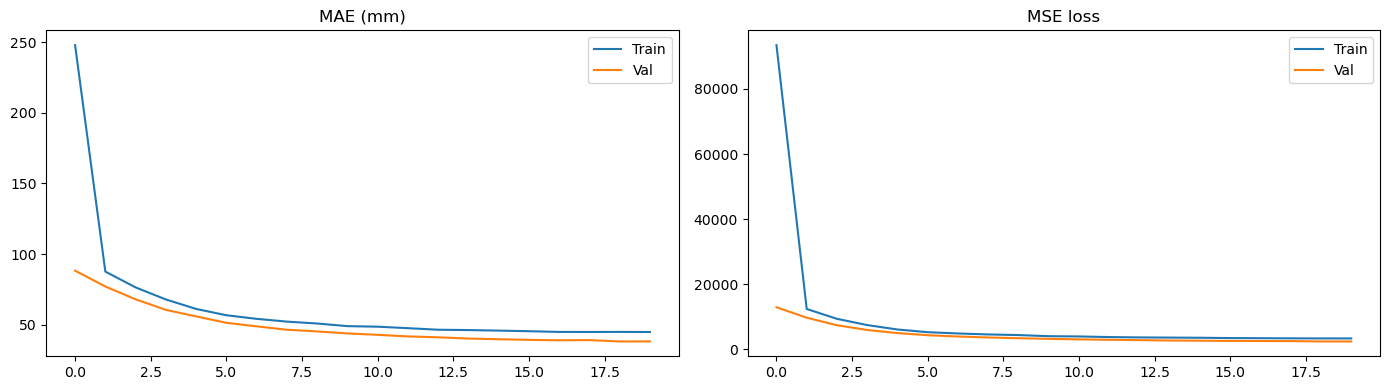

Train  — MSE: 2673.4, MAE: 39.1 mm (3.9 cm)
Val    — MSE: 2464.6, MAE: 38.2 mm (3.8 cm)
Test   — MSE: 3113.0, MAE: 42.1 mm (4.2 cm)


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['mae'],     label='Train')
ax1.plot(history.history['val_mae'], label='Val')
ax1.set_title('MAE (mm)'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('MSE loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, mae = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — MSE: {loss:.1f}, MAE: {mae:.1f} mm ({mae/10:.1f} cm)')

In [29]:
SAVE_PATH = './models/estimator_cont.keras'
estimator.save(SAVE_PATH)
print(f'Saved model to {SAVE_PATH}')

Saved model to ./models/estimator_cont.keras


## Confusion Matrix

Per-image MAE:  42.1 mm (4.2 cm)
Per-image RMSE: 55.8 mm (5.6 cm)
Best-fit slope:     0.851  (1.0 = unbiased)
Best-fit intercept: 71.5 mm


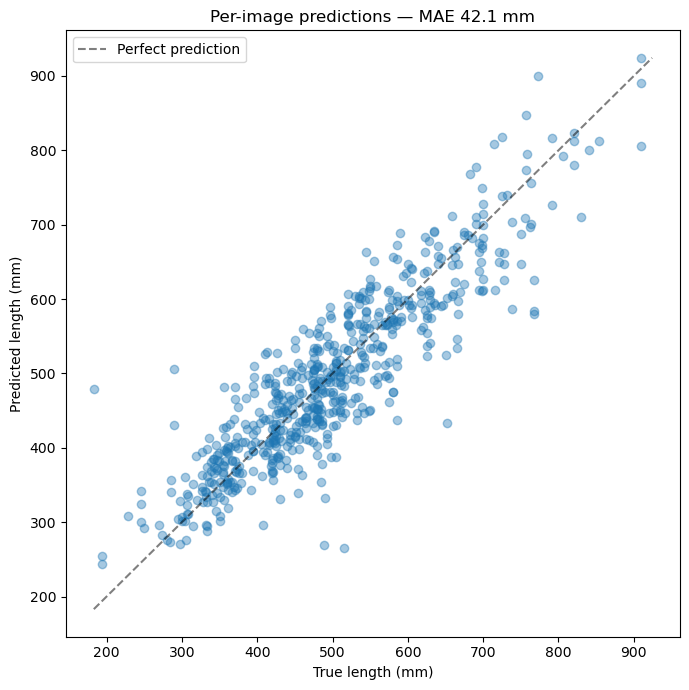

Bin accuracy: 37.76%


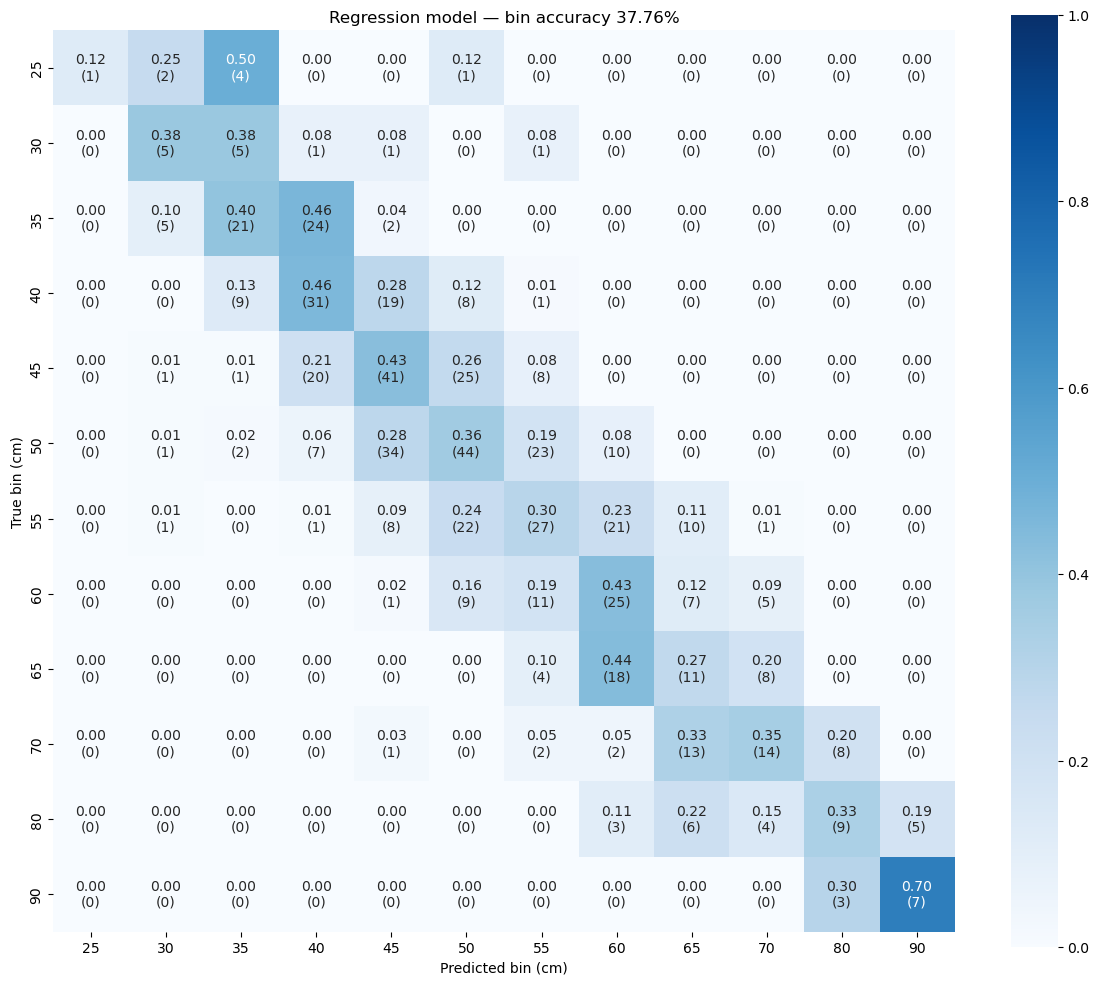

In [30]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

preds_mm = estimator.predict(X_test, verbose=0).squeeze()

# Continuous metrics
per_image_mae = np.mean(np.abs(preds_mm - y_test))
per_image_rmse = np.sqrt(np.mean((preds_mm - y_test) ** 2))
print(f'Per-image MAE:  {per_image_mae:.1f} mm ({per_image_mae/10:.1f} cm)')
print(f'Per-image RMSE: {per_image_rmse:.1f} mm ({per_image_rmse/10:.1f} cm)')

slope, intercept = np.polyfit(y_test, preds_mm, 1)
print(f'Best-fit slope:     {slope:.3f}  (1.0 = unbiased)')
print(f'Best-fit intercept: {intercept:.1f} mm')

# Scatter: true vs predicted
plt.figure(figsize=(7, 7))
lo, hi = min(y_test.min(), preds_mm.min()), max(y_test.max(), preds_mm.max())
plt.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Perfect prediction')
plt.scatter(y_test, preds_mm, alpha=0.4)
plt.xlabel('True length (mm)'); plt.ylabel('Predicted length (mm)')
plt.title(f'Per-image predictions — MAE {per_image_mae:.1f} mm')
plt.legend(); plt.tight_layout(); plt.show()

# Bin-level accuracy for comparison with Silva
def lengths_to_bins(lengths_mm):
    bins = []
    for L in lengths_mm:
        b = length_to_bin(L)
        bins.append(b if b is not None else NUM_SIZE_BINS - 1)
    return np.array(bins, dtype=int)

y_pred_bins = lengths_to_bins(preds_mm)
y_true_bins = lengths_to_bins(y_test)
bin_acc = np.mean(y_pred_bins == y_true_bins)
print(f'Bin accuracy: {bin_acc:.2%}')

cm      = confusion_matrix(y_true_bins, y_pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'Regression model — bin accuracy {bin_acc:.2%}')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()

In [31]:
# ── 20-run experiment — continuous estimator ──────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

NUM_RUNS = 20
ESTIMATOR_EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

# Pool all data
print('Pooling all data...')
X_all, y_all = folds_to_arrays(train_pkl_folds + test_pkl_folds)
print(f'Total: {X_all.shape[0]} images\n')

def lengths_to_bins(lengths_mm):
    bins = []
    for L in lengths_mm:
        b = length_to_bin(L)
        bins.append(b if b is not None else NUM_SIZE_BINS - 1)
    return np.array(bins, dtype=int)

# Run loop
results = []
all_cm = np.zeros((NUM_SIZE_BINS, NUM_SIZE_BINS), dtype=np.float64)

for run in range(NUM_RUNS):
    seed = run
    print(f'═══ Run {run + 1}/{NUM_RUNS}  (seed={seed}) ═══')

    # 80/10/10 split at image level (matching Silva)
    X_tr, X_temp, y_tr, y_temp = train_test_split(X_all, y_all, test_size=0.2, random_state=seed)
    X_v, X_te, y_v, y_te       = train_test_split(X_temp, y_temp, test_size=0.5, random_state=seed)

    # Build datasets
    train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, y_tr))
                .shuffle(len(X_tr), seed=seed).batch(BATCH_SIZE).prefetch(AUTOTUNE))
    val_ds   = (tf.data.Dataset.from_tensor_slices((X_v, y_v))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

    # Fresh model each run
    model = build_estimator(trainable_backbone=False)
    early_stop = EarlyStopping(monitor='val_mae', mode='min', patience=3, restore_best_weights=True)
    model.fit(train_ds, validation_data=val_ds, epochs=ESTIMATOR_EPOCHS,
              callbacks=[early_stop], verbose=0)

    # Predict
    preds_mm = model.predict(X_te, verbose=0).squeeze()

    # Continuous metrics
    mae_mm = np.mean(np.abs(preds_mm - y_te))
    rmse_mm = np.sqrt(np.mean((preds_mm - y_te) ** 2))

    # Bin accuracy (for comparison with Silva / bin estimator)
    y_pred_bins = lengths_to_bins(preds_mm)
    y_true_bins = lengths_to_bins(y_te)
    bin_acc = np.mean(y_pred_bins == y_true_bins)

    results.append({
        'run': run + 1,
        'seed': seed,
        'mae_mm': mae_mm,
        'mae_cm': mae_mm / 10,
        'rmse_mm': rmse_mm,
        'bin_accuracy': bin_acc,
    })
    print(f'  MAE: {mae_mm:.1f} mm ({mae_mm/10:.1f} cm)  RMSE: {rmse_mm:.1f} mm  Bin acc: {bin_acc:.2%}\n')

    # Accumulate normalised confusion matrix
    cm = confusion_matrix(y_true_bins, y_pred_bins, labels=list(range(NUM_SIZE_BINS)))
    row_sum = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sum == 0, 0, cm / np.where(row_sum == 0, 1, row_sum))
    all_cm += cm_norm

    # Free memory
    del model, preds_mm, X_tr, X_v, X_te
    tf.keras.backend.clear_session()

Pooling all data...
  Loaded 6246 images from 694 fish, skipped 0 fish
Total: 6246 images

═══ Run 1/20  (seed=0) ═══


KeyboardInterrupt: 

In [ ]:
# ── Summary ───────────────────────────────────────────────────────────────────
import pandas as pd

df = pd.DataFrame(results)
print(df.to_string(index=False))
print(f'\nMAE:          {df["mae_mm"].mean():.1f} ± {df["mae_mm"].std():.1f} mm '
      f'({df["mae_cm"].mean():.1f} ± {df["mae_cm"].std():.1f} cm)')
print(f'RMSE:         {df["rmse_mm"].mean():.1f} ± {df["rmse_mm"].std():.1f} mm')
print(f'Bin accuracy: {df["bin_accuracy"].mean():.2%} ± {df["bin_accuracy"].std():.2%}')

 run  seed    mae_mm   mae_cm   rmse_mm  bin_accuracy
   1     0 39.977276 3.997728 52.203743        0.4160
   2     1 39.305664 3.930566 51.272682        0.3920
   3     2 41.604321 4.160432 53.853931        0.3952
   4     3 39.173203 3.917320 51.069706        0.4112
   5     4 37.920036 3.792004 50.512016        0.4224
   6     5 39.326599 3.932660 51.849949        0.4256
   7     6 42.020580 4.202058 54.351814        0.3664
   8     7 40.714760 4.071476 53.361965        0.4192
   9     8 39.995808 3.999581 53.614021        0.3840
  10     9 41.973412 4.197341 56.984207        0.4016
  11    10 41.288067 4.128807 53.350285        0.3856
  12    11 40.140076 4.014008 54.359619        0.4048
  13    12 39.176849 3.917685 51.754539        0.4032
  14    13 40.301083 4.030108 52.017166        0.3792
  15    14 40.970348 4.097035 54.700363        0.4224
  16    15 42.918152 4.291815 54.622974        0.3456

MAE:          40.4 ± 1.3 mm (4.0 ± 0.1 cm)
RMSE:         53.1 ± 1.7 mm
Bin accura